In [ ]:
import cv2, numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


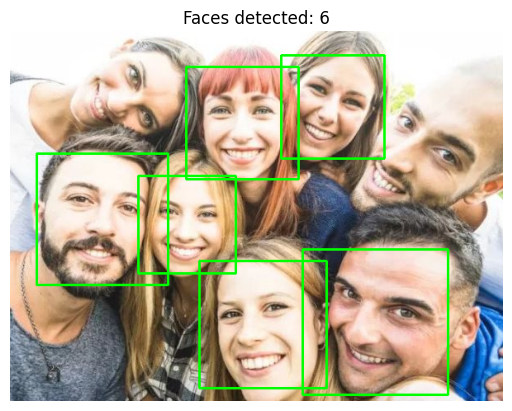

In [ ]:
img = cv2.imread("/content/drive/MyDrive/Computer Vision/dataset/peoples.JPG")
assert img is not None, "people.jpg tidak ditemukan (placeholder). Ganti dengan foto manusia untuk deteksi yang akurat."
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30,30))
for (x,y,w,h) in faces:
    cv2.rectangle(img, (x,y), (x+w, y+h), (0,255,0), 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.title(f'Faces detected: {len(faces)}'); plt.show()
# Deteksi dari webcam (aktifkan saat offline/PC lokal)
# cap = cv2.VideoCapture(0)
# while True:
# ret, frame = cap.read()
# if not ret: break
# gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
# faces = face_cascade.detectMultiScale(gray, 1.1, 5)
# for (x,y,w,h) in faces:
# cv2.rectangle(frame, (x,y), (x+w, y+h), (0,255,0), 2)
# cv2.imshow('Webcam Face Detection', frame)
# if cv2.waitKey(1) & 0xFF == ord('q'): break
# cap.release(); cv2.destroyAllWindows()

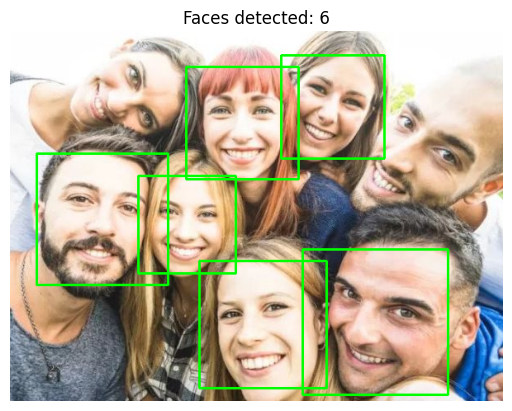

In [ ]:
# Load cascade classifier
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
# Baca gambar
img2 = cv2.imread("/content/drive/MyDrive/Computer Vision/dataset/peoples.JPG")
gray = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
# Deteksi wajah
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))
# Gambar kotak di sekitar wajah
for (x, y, w, h) in faces:
    cv2.rectangle(img2, (x, y), (x+w, y+h), (0, 255, 0), 2)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.title(f'Faces detected: {len(faces)}'); plt.show()
#cv2.imshow("Deteksi Wajah", img2)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [ ]:
 !pip install mtcnn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 48.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 56.1 MB/s eta 0:00:00


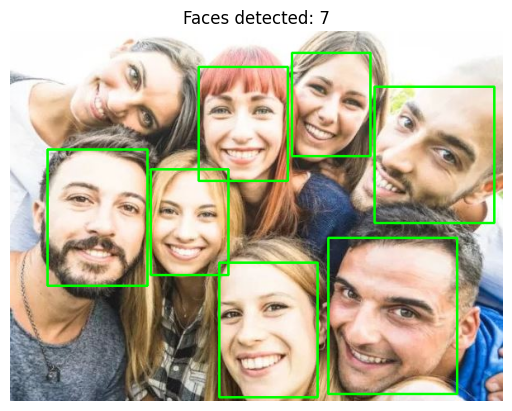

In [21]:
from mtcnn import MTCNN
import cv2
img = cv2.imread("/content/drive/MyDrive/Computer Vision/dataset/peoples.JPG")
rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
detector = MTCNN()
faces = detector.detect_faces(rgb_img)
for face in faces:
    x, y, w, h = face['box']
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); plt.axis('off'); plt.title(f'Faces detected: {len(faces)}'); plt.show()
cv2.waitKey(0)
cv2.destroyAllWindows()

In [23]:
from mtcnn import MTCNN
import cv2
import time
# Load model CNN MTCNN
detector = MTCNN()
# Buka video (atau webcam: 0)
video_path = "video_sample.mp4"
cap = cv2.VideoCapture(video_path)
prev_time = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    # Konversi ke RGB (karena MTCNN butuh RGB)
    rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    # Deteksi wajah
    faces = detector.detect_faces(rgb_frame)
    # Gambar bounding box dan landmark
    for face in faces:
        x, y, w, h = face['box']
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
        for key, point in face['keypoints'].items():
            cv2.circle(frame, point, 2, (0, 0, 255), -1)
    # Hitung FPS
    current_time = time.time()
    fps = 1 / (current_time - prev_time) if prev_time else 0
    prev_time = current_time
    cv2.putText(frame, f"FPS: {fps:.2f}", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    # Tampilkan hasil
    cv2.imshow("Deteksi Wajah CNN (MTCNN)", frame)
    if cv2.waitKey(1) & 0xFF == 27: # Tekan ESC
        break
cap.release()
cv2.destroyAllWindows()

In [ ]:
pip install ultralytics opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.7 MB/s eta 0:00:00


In [24]:
from ultralytics import YOLO
import cv2
import time
import os
import requests # Import the requests library for downloading files

# Check if the model file exists, if not, download it
model_name = "yolov8n-face.pt"
if not os.path.exists(model_name):
    print(f"Downloading {model_name}...")
    # Using a new community source for yolov8n-face.pt
    # Source: https://github.com/yemreak/YOLOv8_Face_Detection/releases
    download_url = "https://github.com/yemreak/YOLOv8_Face_Detection/releases/download/v1.0.0/yolov8n-face.pt"
    try:
        response = requests.get(download_url, stream=True)
        response.raise_for_status() # Raise an HTTPError for bad responses (4xx or 5xx)
        with open(model_name, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print(f"Successfully downloaded {model_name}")
    except requests.exceptions.RequestException as e:
        print(f"Failed to download {model_name}: {e}")
        print("Please ensure the download URL is correct and accessible. You might need to manually download the model.")
        raise FileNotFoundError(f"Model file '{model_name}' is missing and could not be downloaded automatically.")

# Load model YOLOv8-face (pastikan file 'yolov8n-face.pt' tersedia atau otomatis diunduh)
model = YOLO(model_name)

# Buka file video (atau webcam: 0)
video_path = "video_sample.mp4" # Ganti dengan nama file video kamu
cap = cv2.VideoCapture(video_path)

# Untuk menghitung FPS
prev_time = 0
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Jalankan deteksi wajah dengan YOLO
    results = model(frame, verbose=False)
    annotated_frame = results[0].plot()

    # Hitung FPS
    current_time = time.time()
    fps = 1 / (current_time - prev_time) if prev_time else 0
    prev_time = current_time

    # Tampilkan FPS
    cv2.putText(annotated_frame, f"FPS: {fps:.2f}", (20, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # Tampilkan hasil
    cv2.imshow("YOLOv8 Face Detection (Video)", annotated_frame)

    # Tekan ESC untuk keluar
    if cv2.waitKey(1) & 0xFF == 27:
        break

cap.release()
cv2.destroyAllWindows()

Failed to download yolov8n-face.pt: 404 Client Error: Not Found for url: https://github.com/yemreak/YOLOv8_Face_Detection/releases/download/v1.0.0/yolov8n-face.pt
Please ensure the download URL is correct and accessible. You might need to manually download the model.


FileNotFoundError: Model file 'yolov8n-face.pt' is missing and could not be downloaded automatically.

In [25]:
!ls -l yolov8n-face.pt

ls: cannot access 'yolov8n-face.pt': No such file or directory
